# 🤖 Half-Body Humanoid Robot — PyBullet Simulation

**Robot specs:**
- `l1 = 0.065 m` — Upper leg (thigh)
- `l2 = 0.055 m` — Lower leg (shin)
- `l3 = 0.015 m` — Foot height
- 6 active DoF: hip / knee / ankle pitch × 2 legs


In [3]:
!pip install pybullet
print('All packages installed')

  Using cached pybullet-3.2.7.tar.gz (80.5 MB)
  Preparing metadata (setup.py) ... done
  Created wheel for pybullet: filename=pybullet-3.2.7-cp312-cp312-linux_x86_64.whl size=99873184 sha256=16fc4db1824d1a2bac572aab36f19f58987f9f7d74fbcc3df86863a7ccac45bd
  Stored in directory: /root/.cache/pip/wheels/72/95/1d/b336e5ee612ae9a019bfff4dc0bedd100ee6f0570db205fdf8
Successfully built pybullet
All packages installed


In [4]:
!pip install Pillow imageio ipywidgets --quiet

In [5]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import math, os, time, imageio
from PIL import Image as PILImage
from IPython.display import Image, display
print('Imports OK')
print('PyBullet version:', p.getAPIVersion())

Imports OK
PyBullet version: 202010061


In [6]:
URDF = """
<?xml version="1.0"?>
<robot name="humanoid">

  <material name="blk"><color rgba="0.1 0.1 0.1 1"/></material>
  <material name="blu"><color rgba="0.1 0.3 0.8 1"/></material>

  <link name="pelvis">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.12 0.04 0.03"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.12 0.04 0.03"/></geometry></collision>
    <inertial><mass value="0.15"/><inertia ixx="5e-5" ixy="0" ixz="0" iyy="2e-4" iyz="0" izz="2.2e-4"/></inertial>
  </link>

  <link name="l_hip_brk">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.03 0.03 0.025"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.03 0.03 0.025"/></geometry></collision>
    <inertial><mass value="0.03"/><inertia ixx="3e-6" ixy="0" ixz="0" iyy="3e-6" iyz="0" izz="3e-6"/></inertial>
  </link>
  <link name="l_uleg">
    <visual><origin xyz="0 0 -0.0325" rpy="0 0 0"/><geometry><box size="0.025 0.025 0.065"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 -0.0325" rpy="0 0 0"/><geometry><box size="0.025 0.025 0.065"/></geometry></collision>
    <inertial><mass value="0.04"/><origin xyz="0 0 -0.0325"/><inertia ixx="1.5e-5" ixy="0" ixz="0" iyy="1.5e-5" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="l_knee_srv">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry><material name="blu"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry></collision>
    <inertial><mass value="0.017"/><inertia ixx="2e-6" ixy="0" ixz="0" iyy="1e-6" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="l_lleg">
    <visual><origin xyz="0 0 -0.0275" rpy="0 0 0"/><geometry><box size="0.022 0.022 0.055"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 -0.0275" rpy="0 0 0"/><geometry><box size="0.022 0.022 0.055"/></geometry></collision>
    <inertial><mass value="0.035"/><origin xyz="0 0 -0.0275"/><inertia ixx="1e-5" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="l_ank_srv">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry><material name="blu"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry></collision>
    <inertial><mass value="0.017"/><inertia ixx="2e-6" ixy="0" ixz="0" iyy="1e-6" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="l_foot">
    <visual><origin xyz="0.01 0 -0.0075" rpy="0 0 0"/><geometry><box size="0.07 0.04 0.015"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0.01 0 -0.0075" rpy="0 0 0"/><geometry><box size="0.07 0.04 0.015"/></geometry></collision>
    <inertial><mass value="0.025"/><origin xyz="0.01 0 -0.0075"/><inertia ixx="5e-6" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1.2e-5"/></inertial>
  </link>

  <link name="r_hip_brk">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.03 0.03 0.025"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.03 0.03 0.025"/></geometry></collision>
    <inertial><mass value="0.03"/><inertia ixx="3e-6" ixy="0" ixz="0" iyy="3e-6" iyz="0" izz="3e-6"/></inertial>
  </link>
  <link name="r_uleg">
    <visual><origin xyz="0 0 -0.0325" rpy="0 0 0"/><geometry><box size="0.025 0.025 0.065"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 -0.0325" rpy="0 0 0"/><geometry><box size="0.025 0.025 0.065"/></geometry></collision>
    <inertial><mass value="0.04"/><origin xyz="0 0 -0.0325"/><inertia ixx="1.5e-5" ixy="0" ixz="0" iyy="1.5e-5" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="r_knee_srv">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry><material name="blu"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry></collision>
    <inertial><mass value="0.017"/><inertia ixx="2e-6" ixy="0" ixz="0" iyy="1e-6" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="r_lleg">
    <visual><origin xyz="0 0 -0.0275" rpy="0 0 0"/><geometry><box size="0.022 0.022 0.055"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0 0 -0.0275" rpy="0 0 0"/><geometry><box size="0.022 0.022 0.055"/></geometry></collision>
    <inertial><mass value="0.035"/><origin xyz="0 0 -0.0275"/><inertia ixx="1e-5" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="r_ank_srv">
    <visual><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry><material name="blu"/></visual>
    <collision><origin xyz="0 0 0" rpy="0 0 0"/><geometry><box size="0.023 0.012 0.029"/></geometry></collision>
    <inertial><mass value="0.017"/><inertia ixx="2e-6" ixy="0" ixz="0" iyy="1e-6" iyz="0" izz="1e-6"/></inertial>
  </link>
  <link name="r_foot">
    <visual><origin xyz="0.01 0 -0.0075" rpy="0 0 0"/><geometry><box size="0.07 0.04 0.015"/></geometry><material name="blk"/></visual>
    <collision><origin xyz="0.01 0 -0.0075" rpy="0 0 0"/><geometry><box size="0.07 0.04 0.015"/></geometry></collision>
    <inertial><mass value="0.025"/><origin xyz="0.01 0 -0.0075"/><inertia ixx="5e-6" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1.2e-5"/></inertial>
  </link>

  <joint name="l_hip_brk_j" type="fixed"><parent link="pelvis"/><child link="l_hip_brk"/><origin xyz="-0.045 0 -0.0275" rpy="0 0 0"/></joint>
  <joint name="l_hip_pitch" type="revolute"><parent link="l_hip_brk"/><child link="l_uleg"/><origin xyz="0 0 -0.0125" rpy="0 0 0"/><axis xyz="0 1 0"/><limit lower="-1.5708" upper="1.5708" effort="3" velocity="6"/><dynamics damping="0.05" friction="0.01"/></joint>
  <joint name="l_knee_pitch" type="revolute"><parent link="l_uleg"/><child link="l_knee_srv"/><origin xyz="0 0 -0.065" rpy="0 0 0"/><axis xyz="0 1 0"/><limit lower="-0.1745" upper="2.0944" effort="3" velocity="6"/><dynamics damping="0.05" friction="0.01"/></joint>
  <joint name="l_knee_fix" type="fixed"><parent link="l_knee_srv"/><child link="l_lleg"/><origin xyz="0 0 0" rpy="0 0 0"/></joint>
  <joint name="l_ank_pitch" type="revolute"><parent link="l_lleg"/><child link="l_ank_srv"/><origin xyz="0 0 -0.055" rpy="0 0 0"/><axis xyz="0 1 0"/><limit lower="-1.0472" upper="1.0472" effort="3" velocity="6"/><dynamics damping="0.05" friction="0.01"/></joint>
  <joint name="l_ank_fix" type="fixed"><parent link="l_ank_srv"/><child link="l_foot"/><origin xyz="0 0 0" rpy="0 0 0"/></joint>

  <joint name="r_hip_brk_j" type="fixed"><parent link="pelvis"/><child link="r_hip_brk"/><origin xyz="0.045 0 -0.0275" rpy="0 0 0"/></joint>
  <joint name="r_hip_pitch" type="revolute"><parent link="r_hip_brk"/><child link="r_uleg"/><origin xyz="0 0 -0.0125" rpy="0 0 0"/><axis xyz="0 1 0"/><limit lower="-1.5708" upper="1.5708" effort="3" velocity="6"/><dynamics damping="0.05" friction="0.01"/></joint>
  <joint name="r_knee_pitch" type="revolute"><parent link="r_uleg"/><child link="r_knee_srv"/><origin xyz="0 0 -0.065" rpy="0 0 0"/><axis xyz="0 1 0"/><limit lower="-0.1745" upper="2.0944" effort="3" velocity="6"/><dynamics damping="0.05" friction="0.01"/></joint>
  <joint name="r_knee_fix" type="fixed"><parent link="r_knee_srv"/><child link="r_lleg"/><origin xyz="0 0 0" rpy="0 0 0"/></joint>
  <joint name="r_ank_pitch" type="revolute"><parent link="r_lleg"/><child link="r_ank_srv"/><origin xyz="0 0 -0.055" rpy="0 0 0"/><axis xyz="0 1 0"/><limit lower="-1.0472" upper="1.0472" effort="3" velocity="6"/><dynamics damping="0.05" friction="0.01"/></joint>
  <joint name="r_ank_fix" type="fixed"><parent link="r_ank_srv"/><child link="r_foot"/><origin xyz="0 0 0" rpy="0 0 0"/></joint>

</robot>
"""

with open('/content/humanoid.urdf', 'w') as f:
    f.write(URDF)
print('URDF written to /content/humanoid.urdf')

URDF written to /content/humanoid.urdf


In [7]:
L1 = 0.065
L2 = 0.055
L3 = 0.015
TOTAL_LEG = L1 + L2 + L3
print(f'Leg reach (straight): {TOTAL_LEG*100:.1f} cm')

def leg_ik(x, z, l1=L1, l2=L2):
    d = math.sqrt(x**2 + z**2)
    d = min(d, l1 + l2 - 1e-4)
    cos_k = (l1**2 + l2**2 - d**2) / (2*l1*l2)
    cos_k = max(-1.0, min(1.0, cos_k))
    knee  = math.pi - math.acos(cos_k)
    alpha = math.atan2(-x, -z)
    beta  = math.asin(l2 * math.sin(math.pi - knee) / d)
    hip   = alpha - beta
    return hip, knee

def ankle_comp(hip, knee, target=0.0):
    return -(hip + knee) + target

h, k = leg_ik(0.0, -(L1+L2)*0.9)
a = ankle_comp(h, k)
print(f'IK test: hip={math.degrees(h):.1f} knee={math.degrees(k):.1f} ankle={math.degrees(a):.1f} deg')

Leg reach (straight): 13.5 cm
IK test: hip=-23.6 knee=51.9 ankle=-28.3 deg


In [8]:
try:
    p.disconnect()
except:
    pass

client = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81, physicsClientId=client)
p.setTimeStep(1/240, physicsClientId=client)
p.setRealTimeSimulation(0, physicsClientId=client)

plane = p.loadURDF('plane.urdf', physicsClientId=client)
p.changeDynamics(plane, -1, lateralFriction=0.8, physicsClientId=client)

JOINT_NAMES = ['l_hip_pitch','l_knee_pitch','l_ank_pitch',
               'r_hip_pitch','r_knee_pitch','r_ank_pitch']

robot_id = p.loadURDF(
    '/content/humanoid.urdf',
    basePosition=[0, 0, TOTAL_LEG + 0.04],
    baseOrientation=p.getQuaternionFromEuler([0,0,0]),
    useFixedBase=False,
    flags=p.URDF_USE_INERTIA_FROM_FILE,
    physicsClientId=client
)

jmap = {}
for i in range(p.getNumJoints(robot_id, physicsClientId=client)):
    info = p.getJointInfo(robot_id, i, physicsClientId=client)
    jmap[info[1].decode()] = i

active = [jmap[n] for n in JOINT_NAMES]

for j in active:
    p.setJointMotorControl2(robot_id, j, p.VELOCITY_CONTROL,
                            force=0, physicsClientId=client)

VIEW = p.computeViewMatrix([0.4,-0.35,0.25],[0,0,0.10],[0,0,1])
PROJ = p.computeProjectionMatrixFOV(55, 4/3, 0.01, 5.0)

def set_joints(angles, force=3.0):
    for idx, ang in zip(active, angles):
        p.setJointMotorControl2(robot_id, idx,
            p.POSITION_CONTROL, targetPosition=ang,
            force=force, positionGain=0.3, velocityGain=0.1,
            physicsClientId=client)

def reset_joints(angles=None):
    if angles is None: angles = [0.0]*6
    for idx, ang in zip(active, angles):
        p.resetJointState(robot_id, idx, ang, physicsClientId=client)

def render(w=480, h=360):
    _, _, px, _, _ = p.getCameraImage(w, h, VIEW, PROJ,
        renderer=p.ER_TINY_RENDERER, physicsClientId=client)
    return np.array(px, dtype=np.uint8).reshape(h, w, 4)[:,:,:3]

def show():
    plt.figure(figsize=(7,5))
    plt.imshow(render())
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Physics world ready. Active joints:', active)

Physics world ready. Active joints: [1, 2, 4, 7, 8, 10]


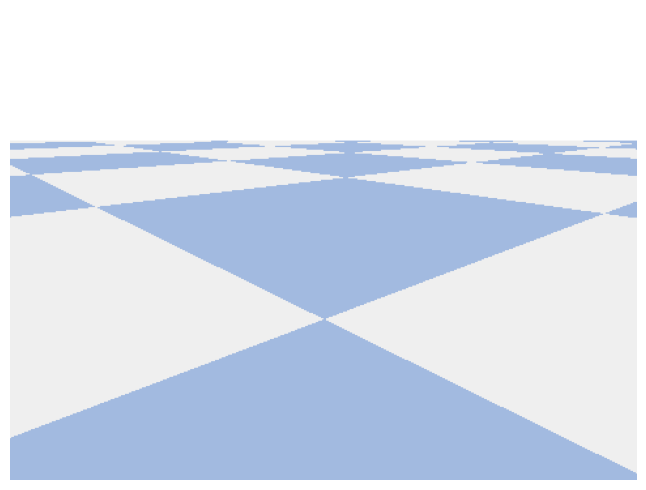

Pelvis height: 717.5 cm


In [9]:
reset_joints()
set_joints([0]*6)
for _ in range(240):
    p.stepSimulation(physicsClientId=client)
show()
pos, _ = p.getBasePositionAndOrientation(robot_id, physicsClientId=client)
print(f'Pelvis height: {pos[2]*100:.1f} cm')

In [10]:
class CPG:
    def __init__(self, freq=0.7, step_h=0.022, step_l=0.012):
        self.freq=freq; self.sh=step_h; self.sl=step_l; self.t=0.0

    def step(self, dt):
        self.t += dt
        phi = 2*math.pi*self.freq*self.t
        z0  = -(L1+L2)*0.88

        lx = math.sin(phi)*self.sl
        lz = z0 + max(0, math.sin(phi))*self.sh
        rx = math.sin(phi+math.pi)*self.sl
        rz = z0 + max(0, math.sin(phi+math.pi))*self.sh

        lh,lk = leg_ik(lx,lz); la = ankle_comp(lh,lk)
        rh,rk = leg_ik(rx,rz); ra = ankle_comp(rh,rk)
        return [lh,lk,la,rh,rk,ra]

print('CPG controller defined')

CPG controller defined


In [11]:
SIM_DT      = 1/240
SIM_SEC     = 4.0
CTRL_HZ     = 50
RENDER_HZ   = 25
CTRL_EVERY  = int(1/(SIM_DT*CTRL_HZ))
REND_EVERY  = int(1/(SIM_DT*RENDER_HZ))
TOTAL_STEPS = int(SIM_SEC/SIM_DT)

p.resetBasePositionAndOrientation(
    robot_id, [0,0,TOTAL_LEG+0.04],
    p.getQuaternionFromEuler([0,0,0]), physicsClientId=client)
p.resetBaseVelocity(robot_id,[0,0,0],[0,0,0],physicsClientId=client)
reset_joints()

gait   = CPG()
frames = []
log_t, log_jp, log_z = [], [], []

print(f'Simulating {SIM_SEC}s ({TOTAL_STEPS} steps)...')

for step in range(TOTAL_STEPS):
    if step % CTRL_EVERY == 0:
        angles = gait.step(SIM_DT*CTRL_EVERY)
        set_joints(angles)
    p.stepSimulation(physicsClientId=client)
    if step % CTRL_EVERY == 0:
        jp = [p.getJointState(robot_id,j,physicsClientId=client)[0] for j in active]
        bz = p.getBasePositionAndOrientation(robot_id,physicsClientId=client)[0][2]
        log_t.append(step*SIM_DT); log_jp.append(jp); log_z.append(bz)
    if step % REND_EVERY == 0:
        frames.append(render())

print(f'Done. Captured {len(frames)} frames.')

gif_path = '/content/humanoid_gait.gif'
imgs = [PILImage.fromarray(f) for f in frames]
imgs[0].save(gif_path, save_all=True, append_images=imgs[1:],
             duration=int(1000/RENDER_HZ), loop=0)
print(f'GIF saved: {gif_path}')

Simulating 4.0s (960 steps)...
Done. Captured 107 frames.
GIF saved: /content/humanoid_gait.gif


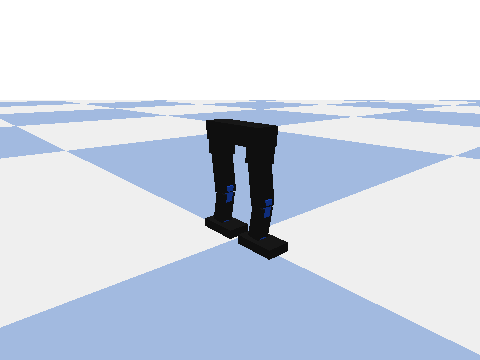

In [12]:
display(Image(filename='/content/humanoid_gait.gif'))

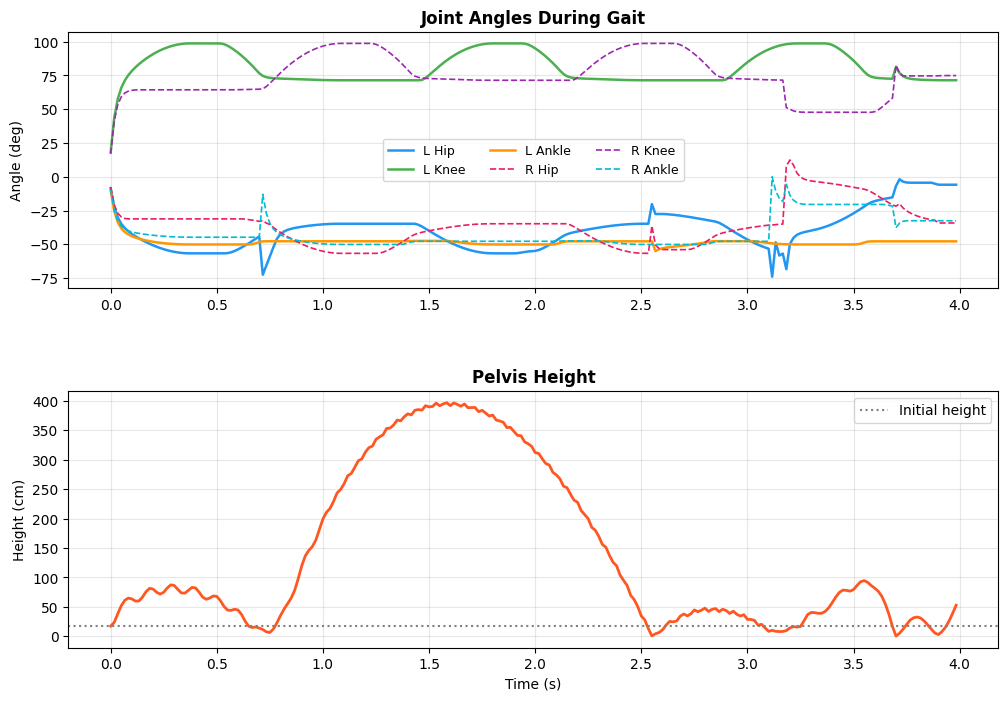

Saved /content/gait_analysis.png


In [13]:
log_jp = np.array(log_jp)
log_t  = np.array(log_t)
log_z  = np.array(log_z)
LABELS = ['L Hip','L Knee','L Ankle','R Hip','R Knee','R Ankle']
COLORS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']

fig, axes = plt.subplots(2,1,figsize=(12,8),gridspec_kw={'hspace':0.4})

ax = axes[0]
for i,(lb,col) in enumerate(zip(LABELS,COLORS)):
    ax.plot(log_t, np.degrees(log_jp[:,i]), label=lb, color=col,
            lw=1.8 if i<3 else 1.2, ls='-' if i<3 else '--')
ax.set_title('Joint Angles During Gait',fontweight='bold')
ax.set_ylabel('Angle (deg)'); ax.legend(ncol=3,fontsize=9)
ax.grid(True,alpha=0.3)

ax = axes[1]
ax.plot(log_t, log_z*100, color='#FF5722', lw=2)
ax.axhline((TOTAL_LEG+0.04)*100, color='gray', ls=':', label='Initial height')
ax.set_title('Pelvis Height',fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Height (cm)')
ax.legend(); ax.grid(True,alpha=0.3)

plt.savefig('/content/gait_analysis.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved /content/gait_analysis.png')

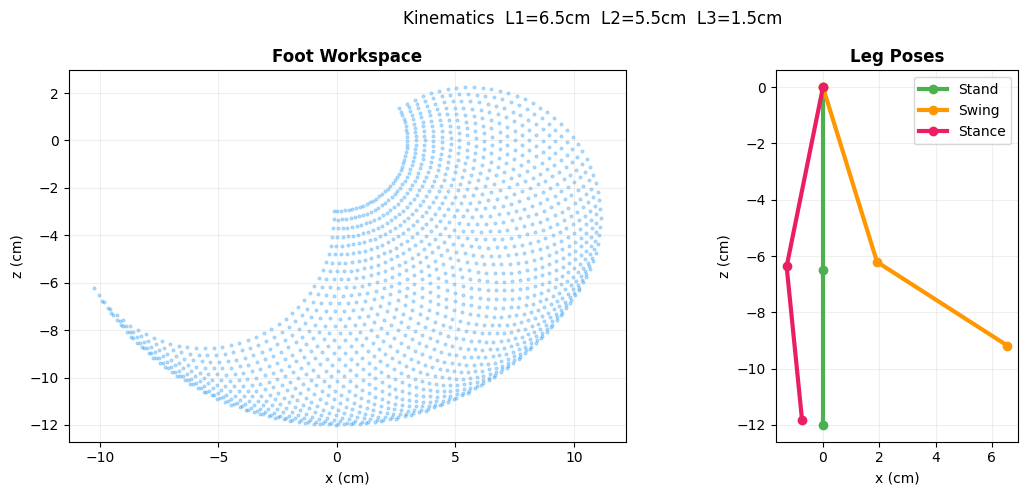

Saved /content/kinematics.png


In [14]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

xs,ys=[],[]
for h in np.linspace(-math.pi/3, math.pi/3, 40):
    for k in np.linspace(0.05, math.pi*0.85, 40):
        fx = L1*math.sin(h) + L2*math.sin(h+k)
        fz = -L1*math.cos(h) - L2*math.cos(h+k)
        xs.append(fx*100); ys.append(fz*100)
axes[0].scatter(xs,ys,s=4,c='#2196F3',alpha=0.3)
axes[0].set_aspect('equal')
axes[0].set_title('Foot Workspace',fontweight='bold')
axes[0].set_xlabel('x (cm)'); axes[0].set_ylabel('z (cm)')
axes[0].grid(True,alpha=0.2)

def draw_leg(ax, hp, kp, col, lbl):
    O  = np.array([0,0])
    K  = O + np.array([L1*math.sin(hp), -L1*math.cos(hp)])*100
    F  = K + np.array([L2*math.sin(hp+kp),-L2*math.cos(hp+kp)])*100
    pts= np.array([O,K,F])
    ax.plot(pts[:,0],pts[:,1],'-o',color=col,lw=3,ms=6,label=lbl)

draw_leg(axes[1], 0.0, 0.0,  '#4CAF50', 'Stand')
draw_leg(axes[1], 0.3, 0.7,  '#FF9800', 'Swing')
draw_leg(axes[1],-0.2, 0.3,  '#E91E63', 'Stance')
axes[1].set_aspect('equal')
axes[1].set_title('Leg Poses',fontweight='bold')
axes[1].set_xlabel('x (cm)'); axes[1].set_ylabel('z (cm)')
axes[1].legend(); axes[1].grid(True,alpha=0.2)

plt.suptitle(f'Kinematics  L1={L1*100:.1f}cm  L2={L2*100:.1f}cm  L3={L3*100:.1f}cm')
plt.tight_layout()
plt.savefig('/content/kinematics.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved /content/kinematics.png')

In [15]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

sliders = [
    widgets.FloatSlider(value=0, min=-90, max=90, step=1,
        description=n, continuous_update=True,
        layout=widgets.Layout(width='450px'))
    for n in ['L Hip','L Knee','L Ankle','R Hip','R Knee','R Ankle']
]
out = widgets.Output()

def on_change(_):
    angles = [math.radians(s.value) for s in sliders]
    reset_joints(angles)
    for _ in range(10): p.stepSimulation(physicsClientId=client)
    with out:
        out.clear_output(wait=True)
        plt.figure(figsize=(6,4.5))
        plt.imshow(render())
        plt.axis('off')
        plt.tight_layout()
        plt.show()

for s in sliders: s.observe(on_change, names='value')
on_change(None)
ipy_display(widgets.VBox(sliders+[out]))

In [16]:
for f in ['/content/humanoid_gait.gif',
          '/content/gait_analysis.png',
          '/content/kinematics.png']:
    if os.path.exists(f):
        print(f'  OK  {f}  ({os.path.getsize(f)//1024} KB)')
print('Done! Right-click any file in the Files panel to download.')

  OK  /content/humanoid_gait.gif  (4 KB)
  OK  /content/gait_analysis.png  (151 KB)
  OK  /content/kinematics.png  (107 KB)
Done! Right-click any file in the Files panel to download.
